#Assignment 01 : Understanding Generative and Discriminative Models Using MNIST



# 1. Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 2. Loading MNIST dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Test images:", X_test.shape)

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


# 3. Select only 0 and 1

In [ ]:

train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

X_train_01 = X_train[train_mask]
y_train_01 = y_train[train_mask]

X_test_01 = X_test[test_mask]
y_test_01 = y_test[test_mask]

print("Training images:", X_train_01.shape)
print("Test images:", X_test_01.shape)

Training images: (12665, 28, 28)
Test images: (2115, 28, 28)


# 4. Normalizing the image (0 -> 1)

In [ ]:

X_train_01 = X_train_01.astype("float32") / 255.0
X_test_01 = X_test_01.astype("float32") / 255.0

# 5. Visualizing some real images

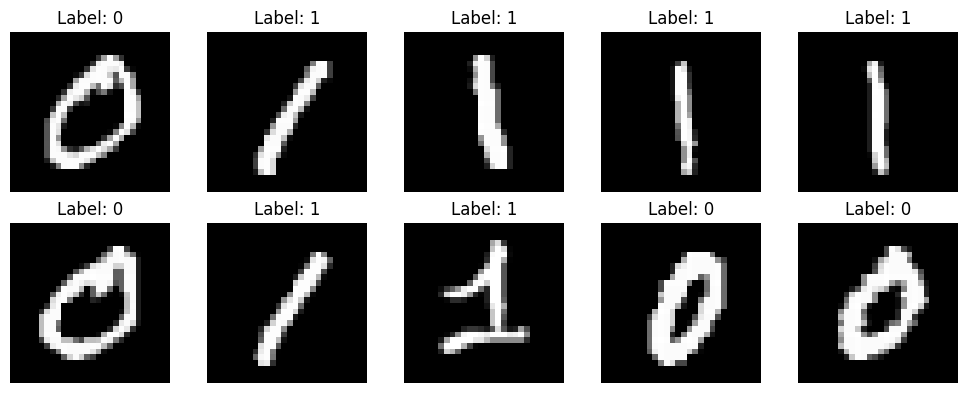

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_01[i], cmap="gray")
    plt.title(f"Label: {y_train_01[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 6. Logistic Regression : Data Preparation for model


In [ ]:
X_train_lr = X_train_01.reshape(X_train_01.shape[0], -1)
X_test_lr = X_test_01.reshape(X_test_01.shape[0], -1)

print("Training data shape:", X_train_lr.shape)
print("Test data shape:", X_test_lr.shape)

Training data shape: (12665, 784)
Test data shape: (2115, 784)


#7. Building the Model

In [ ]:
discriminative_model = LogisticRegression(
    max_iter=1000
)

discriminative_model.fit(X_train_lr, y_train_01)

print("model trained successfully!")

model trained successfully!


#8. Calculate Accuracy

In [ ]:
y_pred = discriminative_model.predict(X_test_lr)

accuracy = accuracy_score(y_test_01, y_pred)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")

Discriminative Model Accuracy: 99.95%


#9. Visualize Predictions

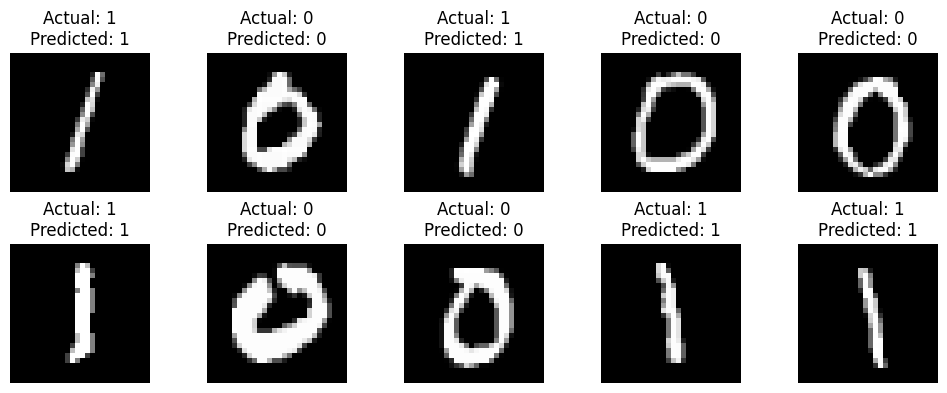

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Actual: {y_test_01[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#10. Auto-Encoder : Data Preparation for Model

In [ ]:
X_train_ae = X_train_01.reshape(X_train_01.shape[0], 784)
X_test_ae = X_test_01.reshape(X_test_01.shape[0], 784)

print("Training shape:", X_train_ae.shape)
print("Test shape:", X_test_ae.shape)

Training shape: (12665, 784)
Test shape: (2115, 784)


#11. Creating the Model

In [ ]:
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(64, activation="relu")(input_img)
latent = Dense(16, activation="relu")(encoded)

# Decoder
decoded = Dense(64, activation="relu")(latent)
output_img = Dense(784, activation="sigmoid")(decoded)

# Autoencoder
autoencoder = Model(input_img, output_img)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,328 (403.62 KB)

 Trainable params: 103,328 (403.62 KB)

 Non-trainable params: 0 (0.00 B)

#12. Training the Auto-Encoder

In [ ]:
history = autoencoder.fit(
    X_train_ae,
    X_train_ae,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_ae, X_test_ae)
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.4000 - val_loss: 0.1888
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1730 - val_loss: 0.1540
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1451 - val_loss: 0.1350
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1331 - val_loss: 0.1279
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1258 - val_loss: 0.1194
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1179 - val_loss: 0.1128
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1122 - val_loss: 0.1079
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1083 - val_loss: 0.1047
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1056 - val_loss: 0.1027
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1035 - val_loss: 0.1006
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1014 - val_loss: 0.0986
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0

#13. Plotting the TRAINING LOSS

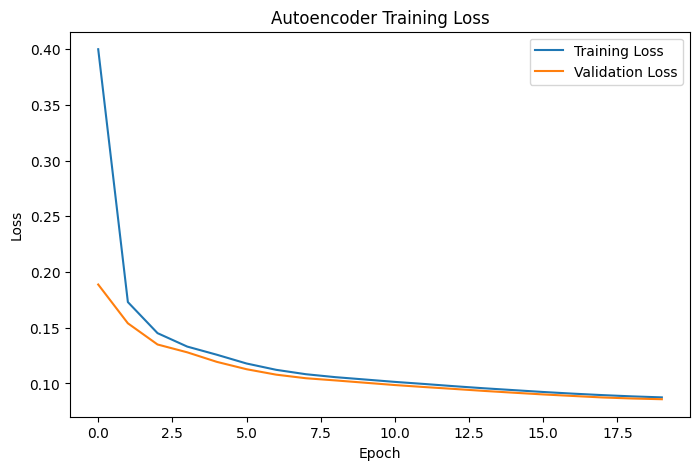

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()

plt.show()

#14. Generation and Visualization of Reconstructed Images


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


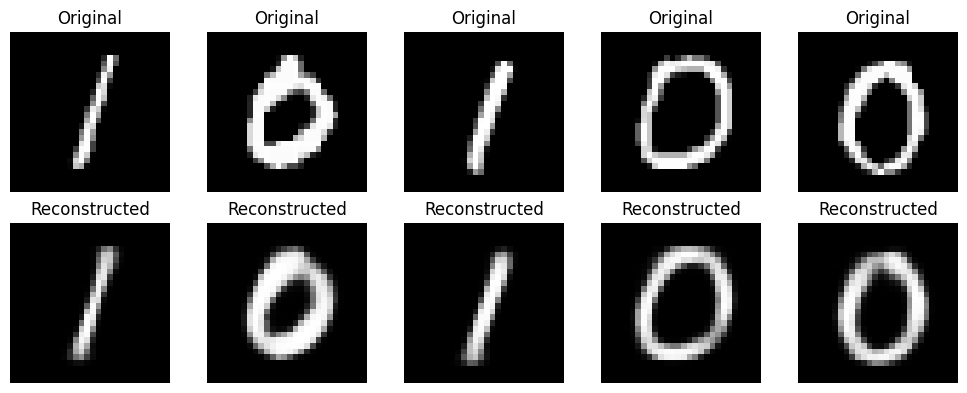

In [ ]:
reconstructed = autoencoder.predict(X_test_ae)

plt.figure(figsize=(10, 4))

for i in range(5):

    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

#15. Generation of New Digit Images

In [ ]:
reconstructed = autoencoder.predict(X_test_ae)

# decoder model :

decoder = Model(
    inputs=latent,
    outputs=output_img
)

# random latent vector :

random_latent_vectors = np.random.normal(
    size=(10, 16)
)
generated_images = decoder.predict(random_latent_vectors)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


#16. Display of the Generated Images

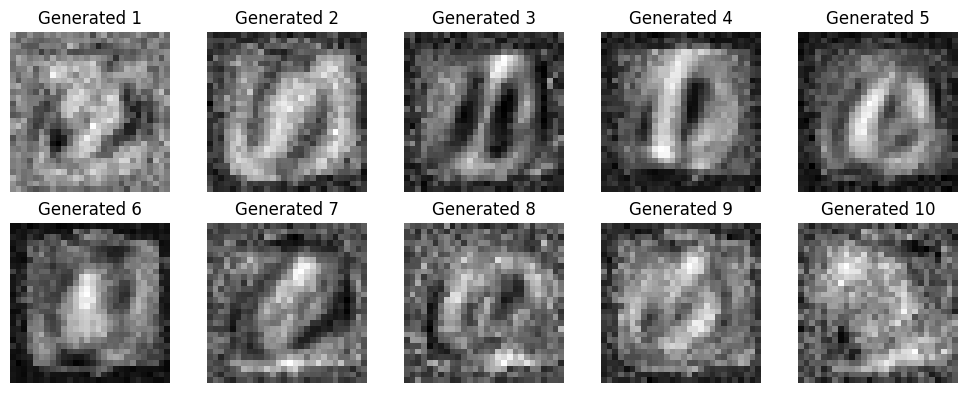

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(f"Generated {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#17. Visual Comparison
REAL IMAGE v/s PREDICTION v/s GENERATED IMAGE


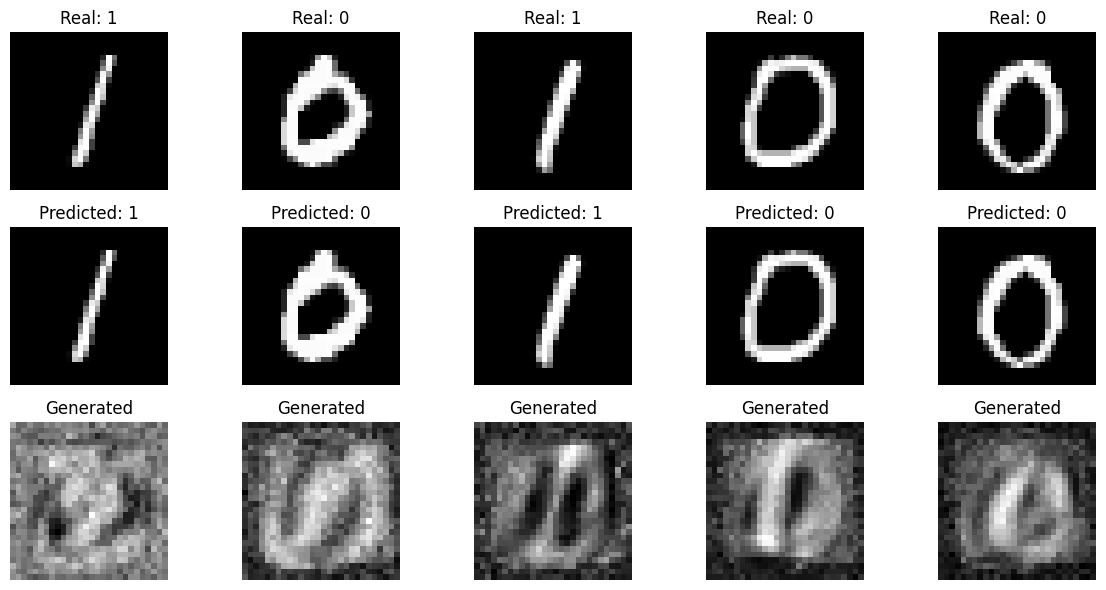

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(5):

    # Real image
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Real: {y_test_01[i]}")
    plt.axis("off")

    # Prediction
    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis("off")

    # Generated
    plt.subplot(3, 5, i + 11)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Written Reflection


The discriminative model learned to distinguish between handwritten 0s and 1s.

The generative model learned the basic patterns of these handwritten digits.

The discriminative model predicts the class of an image, while the generative model reconstructed and created digit-like images.
Thus, the discriminative model is mainly used for classification, whereas the generative model learns the patterns of the data and generate desired output.